<a href="https://colab.research.google.com/github/doa-2026/project4/blob/main/project4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load data

In [5]:
path="/content/drive/MyDrive/adult.csv"
import pandas as pd
df=pd.read_csv(path)
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
#check the datatypes for feature
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


what is the target?  income column , divide to two class >50K and <=50K

what does one row represent ?  it contains 14 columns that describe the individual’s personal information.

no.of feature 15

no.of row 48842

I think we can used overload binary operation between capital and low gain
also used feature selection like filter method , backward wrapper selection

I think facing many challenges in cleaning data (missing data , unique )
preparing object features (value is not logical), scaling data , imbalancing and in choosing the best model

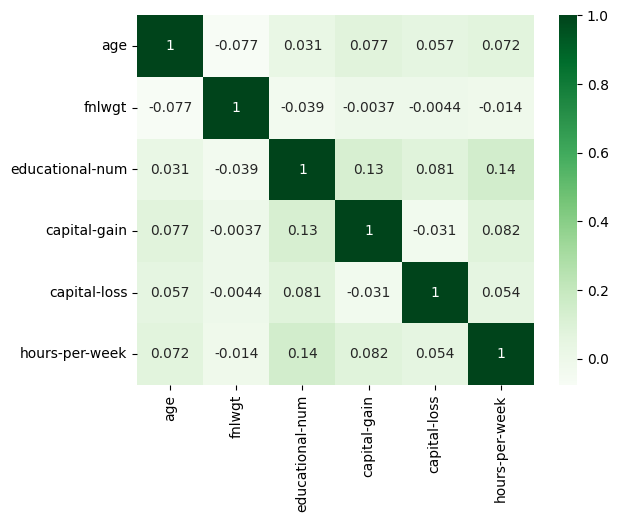

In [9]:
# exploratory visulization
import seaborn as sns
corr=df.corr(numeric_only=True)
ax=sns.heatmap(corr, annot=True,cmap="Greens")
#all the relationship for numeric featuers is low positive and low negative

cleaning data

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [12]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [13]:
o=df.select_dtypes(include="object")
for i in o:
  print (df.value_counts(i))
  print ("\n")


workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64


marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64


occupation
Prof-specialty       6165
Craft-repair         6102
Exec-managerial

In [40]:
#check the inconsistent values
df["occupation"]=df["occupation"].replace({"?":"missing"})
df["native-country"]=df["native-country"].replace({"?":"missing"})
df["workclass"]=df["workclass"].replace({"?":"missing"})
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,missing,103497,Some-college,10,Never-married,missing,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


/tmp/ipykernel_3915/1397650337.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)


[Text(0, 0, 'Private'),
 Text(1, 0, 'Local-gov'),
 Text(2, 0, 'missing'),
 Text(3, 0, 'Self-emp-not-inc'),
 Text(4, 0, 'Federal-gov'),
 Text(5, 0, 'State-gov'),
 Text(6, 0, 'Self-emp-inc'),
 Text(7, 0, 'Without-pay'),
 Text(8, 0, 'Never-worked')]

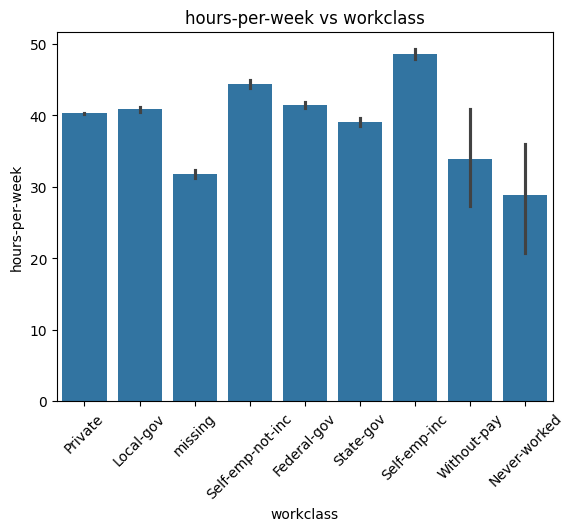

In [41]:
#relation between hour per week and workcalss
ax=sns.barplot(data=df, y="hours-per-week",x="workclass")
ax.set_title("hours-per-week vs workclass")
ax.set_ylabel("hours-per-week")
ax.set_xlabel("workclass")
ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
#the avg num of self-emp-inc is the highest value , the lowest avg num is for never-worked
#the avg of hour per week for the other workcalss between them

Import Packages

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler ,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn import set_config
set_config(transform_output="pandas")



In [16]:
#Perform a validation split
X=df.drop(columns="income")
y=df["income"]
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
#its binary classification

In [17]:
#preproccessing pipline
num_col=X_train.select_dtypes("number").columns
cat_col=X_train.select_dtypes("object").columns
#numerical columns

num_imp=SimpleImputer(strategy="mean")
scale=StandardScaler()
num_pip=make_pipeline(num_imp,scale)
num_tap=("number", num_pip , num_col)

#catagorical columns
cat_imp=SimpleImputer(strategy="constant",fill_value="missing")
encoder=OneHotEncoder(handle_unknown="ignore",sparse_output=False)
cat_pip=make_pipeline(cat_imp,encoder)
cat_tap=("cat",cat_pip,cat_col)


# Colunmn Transformer
preprocessor=ColumnTransformer([num_tap,cat_tap],verbose_feature_names_out=False)




Create default model

In [18]:
rf=RandomForestClassifier(random_state=42)
rf_pipe=make_pipeline(preprocessor,rf)
rf_pipe.fit(X_train,y_train)




Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [19]:
#Evaluate Function
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict



def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict



----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27841
        >50K       1.00      1.00      1.00      8751

    accuracy                           1.00     36592
   macro avg       1.00      1.00      1.00     36592
weighted avg       1.00      1.00      1.00     36592



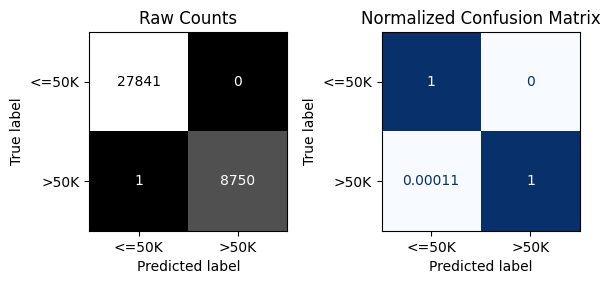


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      9268
        >50K       0.74      0.62      0.68      2930

    accuracy                           0.86     12198
   macro avg       0.81      0.78      0.79     12198
weighted avg       0.85      0.86      0.85     12198



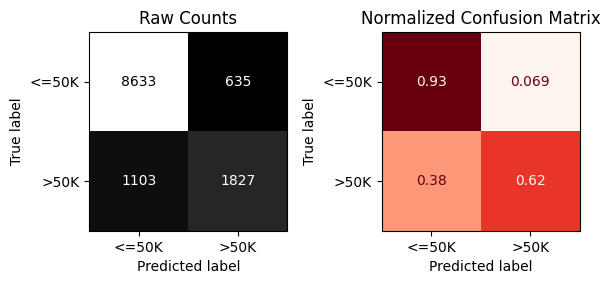

In [20]:
#Evalute the model
evaluate_classification(rf_pipe,X_train,y_train,X_test,y_test)

The result :
the accuracy is .86  

in testing data the recall is .6 and precision is .7 at >50k class

recall .9 and precision is .8 in <=50K class

In [21]:
#Create permutation importance with rf_pip and test data and number of shiffling data (n repeats )
from sklearn.inspection import permutation_importance
r=permutation_importance(rf_pipe,X_test,y_test, n_repeats=3,random_state=42 )


In [22]:
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

In [23]:
#make importance mean to series
p=pd.Series(r["importances_mean"],index=X_test.columns)
p=p.sort_values(ascending=False)
p
p.head(10)

,0
capital-gain,0.041428
marital-status,0.022080
age,0.016314
occupation,0.015030
relationship,0.014920
capital-loss,0.010220
educational-num,0.006149
hours-per-week,0.005247
workclass,0.004290
fnlwgt,0.002159


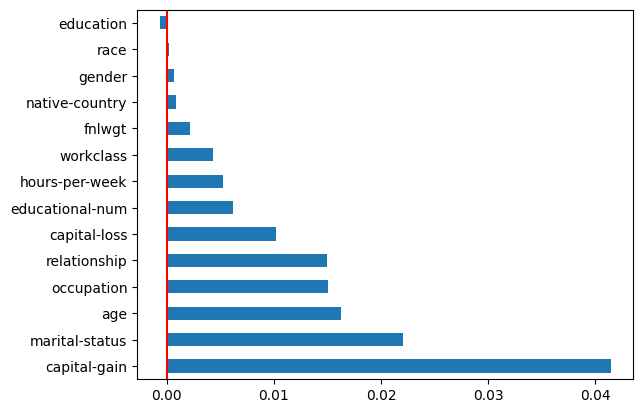

In [24]:
#visualize the top 10 features
ax=p.plot(kind="barh")
ax.axvline(x=0.0,color="red")

**Do these features make sense based on  the bussiness case ?

yes ,,




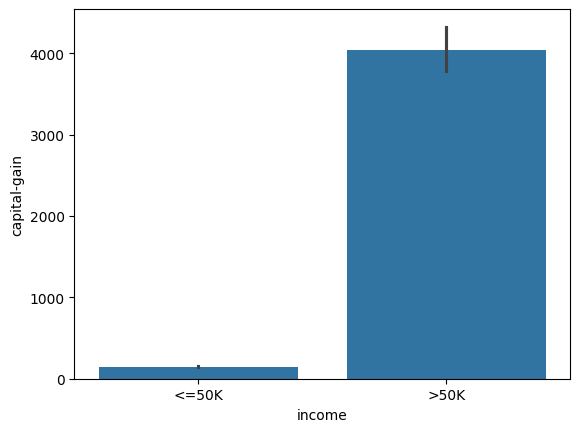

In [25]:
# show the relationship between the capital gain and income (target )
ax=sns.barplot(data=df,y="capital-gain",x="income")
ax.set_title("capital-gain vs income")
ax.set_xlabel("income")
ax.set_ylabel("capital-gain")
#if the income >50K  the average  of  capital gain 4000 , but if income <=50k the average of capital-gain aproximitly 100
#ther are the big different between them

Text(24.0, 0.5, 'income')

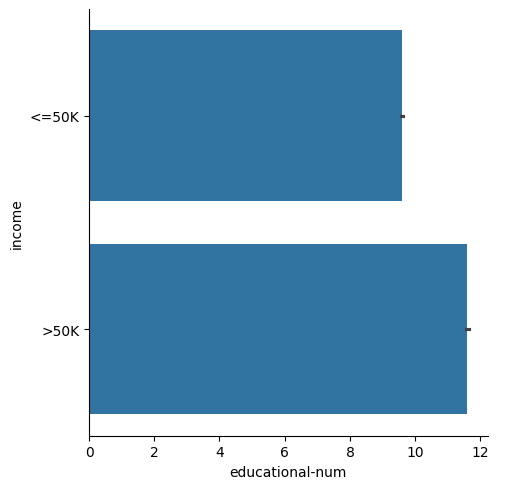

In [34]:
#draw relationship (income and educational-num)
g=sns.catplot(data=df, y="income",x="educational-num", kind="bar")
ax.set_title("income vs educational-num")
ax.set_xlabel("educational-num")
ax.set_ylabel("income")
# the relation between the target (incom) and educational-num , the average of eductional num about 11 when incom >50
#and the average  of eductional num about 10 when incom <=50


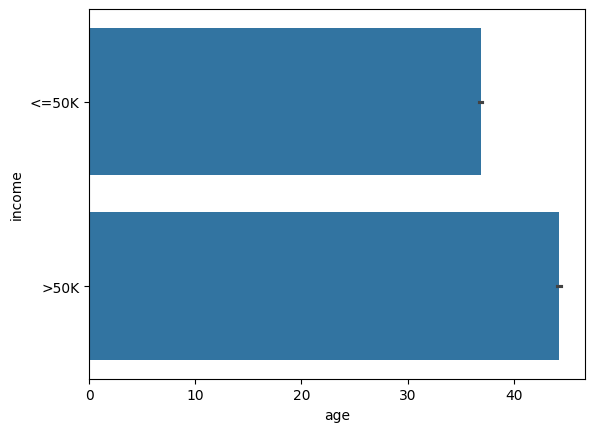

In [32]:
#draw relationship (incom & age)
ax=sns.barplot(data=df, x="age",y="income")
#the income is <=50k  for avg whom is age's is 35 , but the  income is >50k for the avg  age's is 45